In [1]:
import pandas as pd

In [2]:
media_df = pd.read_csv('/content/sample_data/target_crop_discussions_flattened.csv')
display(media_df.head())

,Link,crop_name,issue_type_and_sentiment
0,https://allafrica.com/stories/200002290177.html,sweet potato,{'issue_type': 'support for 500 farm families ...
1,https://allafrica.com/stories/200003250046.html,sorghum,{'issue_type': 'new drought-resistant varietie...
2,https://allafrica.com/stories/200003250046.html,sorghum,"{'issue_type': 'new varieties ripen quickly', ..."
3,https://allafrica.com/stories/200003250046.html,sorghum,{'issue_type': 'plan to propagate new varietie...
4,https://allafrica.com/stories/200005100005.html,sweet potato,{'issue_type': 'suitable for African tastes an...


In [3]:
grants_df = pd.read_csv('/content/sample_data/unique_long_descriptions.csv')
display(grants_df.head())

,long_description
0,to improve the nutritional status in Uganda an...
1,to develop cassava germplasm enriched with bio...
2,to boost the incomes of small-holder farmers i...
3,to develop a next-generation platform to ident...
4,to support increasing skills in cereal rust pa...


In [4]:
import ast

# Function to safely parse the string representation of a dictionary
def parse_dict_string(s):
    try:
        return ast.literal_eval(s)
    except (ValueError, SyntaxError):
        return {} # Return an empty dict for parsing errors

# Apply the function to the 'issue_type_and_sentiment' column of media_df
media_df['parsed_issue_type_sentiment'] = media_df['issue_type_and_sentiment'].apply(parse_dict_string)

# Extract 'issue_type' and handle cases where it might be missing from media_df
media_df['issue_type'] = media_df['parsed_issue_type_sentiment'].apply(lambda x: x.get('issue_type', ''))

# Combine 'crop_name' and 'issue_type' from media_df
media_df['combined_text'] = media_df['crop_name'] + ' ' + media_df['issue_type']

# Select the relevant column from grants_df
grants_df['combined_text'] = grants_df['long_description']

# Concatenate the combined text columns from both dataframes
combined_df = pd.concat([
    media_df['combined_text'],
    grants_df['combined_text']
], ignore_index=True)

# Convert the Series to a DataFrame with a single column and assign a new index
combined_df = combined_df.to_frame(name='combined_text')

# Display the first few rows of the new combined DataFrame
display(combined_df.head())

,combined_text
0,sweet potato support for 500 farm families in ...
1,sorghum new drought-resistant varieties developed
2,sorghum new varieties ripen quickly
3,sorghum plan to propagate new varieties
4,sweet potato suitable for African tastes and c...


In [5]:
total_text = ' '.join(combined_df['combined_text'].astype(str))
estimated_tokens = len(total_text.split())

print(f"Estimated total tokens in combined_df: {estimated_tokens}")

Estimated total tokens in combined_df: 234412


In [6]:
# Randomize row order, then process sequentially so the label vocabulary
# builds from a representative mix rather than being biased by row order
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [7]:
combined_df.head()

,combined_text
0,sorghum low local production of grains
1,banana/plantain can be used as a remedy for co...
2,"sorghum prices decreased in many regions, with..."
3,banana/plantain Banana Bacteria Wilt disease i...
4,cassava funding for production


In [8]:
combined_df.to_csv('/content/sample_data/combined_data.csv', index=False)
print('combined_df saved to /content/sample_data/combined_data.csv')

combined_df saved to /content/sample_data/combined_data.csv


In [12]:
labeled_df = pd.read_csv('/content/sample_data/combined_df_labeled (1).csv')
display(labeled_df.head(50)[['combined_text',	'predicted_labels']])

,combined_text,predicted_labels
0,sorghum low local production of grains,['4a']
1,banana/plantain can be used as a remedy for co...,['11b']
2,"sorghum prices decreased in many regions, with...",['1a']
3,banana/plantain Banana Bacteria Wilt disease i...,['8a']
4,cassava funding for production,['3b']
5,sweet potato Need for capacity building to acc...,['1b']
6,cassava improving income levels,['14a']
7,banana/plantain families can increase their in...,"['1b', '20b']"
8,cassava Bemisia whitefly transmits the deadly ...,['8a']
9,sweet potato,[]


In [13]:
from tabulate import tabulate

# Prepare the data for tabulate, taking the first 50 rows and specific columns
data_to_tabulate = labeled_df.head(50)[['combined_text', 'predicted_labels']]

# Print the DataFrame using tabulate
print(tabulate(data_to_tabulate, headers='keys', tablefmt='psql'))

+----+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------+
|    | combined_text                                                                                                                                                                                                  | predicted_labels     |
|----+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------|
|  0 | sorghum low local production of grains                                                                                                                                                                         | ['4a']               |
|  1 | banana/plantain can be used as a reme

In [14]:
# Columns to merge from labeled_df - only 'predicted_labels' as requested
columns_to_merge = ['combined_text', 'predicted_labels']

# Merge with media_df
# Use 'combined_text' from media_df to match 'combined_text' in labeled_df
media_df_with_labels = pd.merge(media_df, labeled_df[columns_to_merge], on='combined_text', how='left')

# Merge with grants_df
# grants_df's original text content for labeling was its 'long_description'
# So, we match grants_df['long_description'] with labeled_df['combined_text']
grants_df_with_labels = pd.merge(grants_df, labeled_df[columns_to_merge],
                                 left_on='long_description', right_on='combined_text',
                                 how='left')

# Drop the redundant 'combined_text' column from grants_df_with_labels
grants_df_with_labels = grants_df_with_labels.drop(columns=['combined_text'], errors='ignore')

print("--- media_df_with_labels head ---")
display(media_df_with_labels.head())

print("\n--- grants_df_with_labels head ---")
display(grants_df_with_labels.head())

--- media_df_with_labels head ---


,Link,crop_name,issue_type_and_sentiment,parsed_issue_type_sentiment,issue_type,combined_text,predicted_labels
0,https://allafrica.com/stories/200002290177.html,sweet potato,{'issue_type': 'support for 500 farm families ...,{'issue_type': 'support for 500 farm families ...,support for 500 farm families in cultivation,sweet potato support for 500 farm families in ...,['10b']
1,https://allafrica.com/stories/200003250046.html,sorghum,{'issue_type': 'new drought-resistant varietie...,{'issue_type': 'new drought-resistant varietie...,new drought-resistant varieties developed,sorghum new drought-resistant varieties developed,"['6b', '7b']"
2,https://allafrica.com/stories/200003250046.html,sorghum,"{'issue_type': 'new varieties ripen quickly', ...","{'issue_type': 'new varieties ripen quickly', ...",new varieties ripen quickly,sorghum new varieties ripen quickly,['6b']
3,https://allafrica.com/stories/200003250046.html,sorghum,{'issue_type': 'plan to propagate new varietie...,{'issue_type': 'plan to propagate new varietie...,plan to propagate new varieties,sorghum plan to propagate new varieties,['6b']
4,https://allafrica.com/stories/200005100005.html,sweet potato,{'issue_type': 'suitable for African tastes an...,{'issue_type': 'suitable for African tastes an...,suitable for African tastes and climates,sweet potato suitable for African tastes and c...,['20b']



--- grants_df_with_labels head ---


,long_description,combined_text_x,combined_text_y,predicted_labels
0,to improve the nutritional status in Uganda an...,to improve the nutritional status in Uganda an...,to improve the nutritional status in Uganda an...,['11b']
1,to develop cassava germplasm enriched with bio...,to develop cassava germplasm enriched with bio...,to develop cassava germplasm enriched with bio...,['6b']
2,to boost the incomes of small-holder farmers i...,to boost the incomes of small-holder farmers i...,to boost the incomes of small-holder farmers i...,"['4b', '10a']"
3,to develop a next-generation platform to ident...,to develop a next-generation platform to ident...,to develop a next-generation platform to ident...,['6b']
4,to support increasing skills in cereal rust pa...,to support increasing skills in cereal rust pa...,to support increasing skills in cereal rust pa...,['6b']


In [15]:
media_df_with_labels.to_csv('/content/sample_data/media_df_with_labels.csv', index=False)
print('media_df_with_labels saved to /content/sample_data/media_df_with_labels.csv')

media_df_with_labels saved to /content/sample_data/media_df_with_labels.csv


In [16]:
grants_df_with_labels.to_csv('/content/sample_data/grants_df_with_labels.csv', index=False)
print('grants_df_with_labels saved to /content/sample_data/grants_df_with_labels.csv')

grants_df_with_labels saved to /content/sample_data/grants_df_with_labels.csv


### Analyzing Top 10 Labels per Crop per Year for Media Data

I will start by analyzing the `media_df_with_labels` to identify the top 10 predicted labels for each crop per year. The year information can be extracted from the 'Link' column in this DataFrame. I will then perform a similar analysis for `grants_df_with_labels` if you provide guidance on how to derive a year for that dataset.

In [17]:
import re

# Extract year from the 'Link' column in media_df_with_labels
media_df_with_labels['year'] = media_df_with_labels['Link'].apply(lambda x: int(re.search(r'\d{8}', x).group(0)[:4]) if re.search(r'\d{8}', x) else None)

# Drop rows where year could not be extracted
media_df_with_labels.dropna(subset=['year'], inplace=True)
media_df_with_labels['year'] = media_df_with_labels['year'].astype(int)

print("Media DataFrame with 'year' column added:")
display(media_df_with_labels.head())

Media DataFrame with 'year' column added:


,Link,crop_name,issue_type_and_sentiment,parsed_issue_type_sentiment,issue_type,combined_text,predicted_labels,year
0,https://allafrica.com/stories/200002290177.html,sweet potato,{'issue_type': 'support for 500 farm families ...,{'issue_type': 'support for 500 farm families ...,support for 500 farm families in cultivation,sweet potato support for 500 farm families in ...,['10b'],2000
1,https://allafrica.com/stories/200003250046.html,sorghum,{'issue_type': 'new drought-resistant varietie...,{'issue_type': 'new drought-resistant varietie...,new drought-resistant varieties developed,sorghum new drought-resistant varieties developed,"['6b', '7b']",2000
2,https://allafrica.com/stories/200003250046.html,sorghum,"{'issue_type': 'new varieties ripen quickly', ...","{'issue_type': 'new varieties ripen quickly', ...",new varieties ripen quickly,sorghum new varieties ripen quickly,['6b'],2000
3,https://allafrica.com/stories/200003250046.html,sorghum,{'issue_type': 'plan to propagate new varietie...,{'issue_type': 'plan to propagate new varietie...,plan to propagate new varieties,sorghum plan to propagate new varieties,['6b'],2000
4,https://allafrica.com/stories/200005100005.html,sweet potato,{'issue_type': 'suitable for African tastes an...,{'issue_type': 'suitable for African tastes an...,suitable for African tastes and climates,sweet potato suitable for African tastes and c...,['20b'],2000


In [18]:
import ast

# Convert string representation of list to actual list and explode
def parse_labels(labels_str):
    try:
        # Ensure it's treated as a list, even if it's a single string
        if isinstance(labels_str, str):
            return ast.literal_eval(labels_str)
        return []
    except (ValueError, SyntaxError):
        return []

media_df_with_labels['predicted_labels_list'] = media_df_with_labels['predicted_labels'].apply(parse_labels)

# Explode the list of labels so each label gets its own row
media_exploded_labels = media_df_with_labels.explode('predicted_labels_list')

print("Media DataFrame after exploding predicted_labels:")
display(media_exploded_labels.head())

Media DataFrame after exploding predicted_labels:


,Link,crop_name,issue_type_and_sentiment,parsed_issue_type_sentiment,issue_type,combined_text,predicted_labels,year,predicted_labels_list
0,https://allafrica.com/stories/200002290177.html,sweet potato,{'issue_type': 'support for 500 farm families ...,{'issue_type': 'support for 500 farm families ...,support for 500 farm families in cultivation,sweet potato support for 500 farm families in ...,['10b'],2000,10b
1,https://allafrica.com/stories/200003250046.html,sorghum,{'issue_type': 'new drought-resistant varietie...,{'issue_type': 'new drought-resistant varietie...,new drought-resistant varieties developed,sorghum new drought-resistant varieties developed,"['6b', '7b']",2000,6b
1,https://allafrica.com/stories/200003250046.html,sorghum,{'issue_type': 'new drought-resistant varietie...,{'issue_type': 'new drought-resistant varietie...,new drought-resistant varieties developed,sorghum new drought-resistant varieties developed,"['6b', '7b']",2000,7b
2,https://allafrica.com/stories/200003250046.html,sorghum,"{'issue_type': 'new varieties ripen quickly', ...","{'issue_type': 'new varieties ripen quickly', ...",new varieties ripen quickly,sorghum new varieties ripen quickly,['6b'],2000,6b
3,https://allafrica.com/stories/200003250046.html,sorghum,{'issue_type': 'plan to propagate new varietie...,{'issue_type': 'plan to propagate new varietie...,plan to propagate new varieties,sorghum plan to propagate new varieties,['6b'],2000,6b


In [19]:
# Group by crop_name, year, and predicted_labels_list to count occurrences
top_labels_per_crop_year = media_exploded_labels.groupby(['crop_name', 'year', 'predicted_labels_list']).size().reset_index(name='count')

# Get the top 10 labels for each crop and year
top_10_labels = top_labels_per_crop_year.groupby(['crop_name', 'year']).apply(lambda x: x.nlargest(10, 'count')).reset_index(drop=True)

print("Top 10 labels for each crop per year:")
display(top_10_labels)

# Optionally, display for a specific crop and year as an example
# if not top_10_labels.empty:
#     example_crop = top_10_labels['crop_name'].iloc[0]
#     example_year = top_10_labels['year'].iloc[0]
#     print(f"\nExample for {example_crop} in {example_year}:")
#     display(top_10_labels[(top_10_labels['crop_name'] == example_crop) & (top_10_labels['year'] == example_year)])

Top 10 labels for each crop per year:


/tmp/ipykernel_6429/2486349289.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_10_labels = top_labels_per_crop_year.groupby(['crop_name', 'year']).apply(lambda x: x.nlargest(10, 'count')).reset_index(drop=True)


,crop_name,year,predicted_labels_list,count
0,banana/plantain,2001,20a,2
1,banana/plantain,2001,5b,2
2,banana/plantain,2001,11b,1
3,banana/plantain,2001,20b,1
4,banana/plantain,2002,20b,6
...,...,...,...,...
1208,yam,2024,11a,1
1209,yam,2024,2a,1
1210,yam,2024,4a,1
1211,yam,2024,5a,1


In [20]:
import ast

# Convert string representation of list to actual list and explode
# Assuming grants_df_with_labels also has a 'predicted_labels' column
def parse_labels(labels_str):
    try:
        # Ensure it's treated as a list, even if it's a single string
        if isinstance(labels_str, str):
            return ast.literal_eval(labels_str)
        return []
    except (ValueError, SyntaxError):
        return []

grants_df_with_labels['predicted_labels_list'] = grants_df_with_labels['predicted_labels'].apply(parse_labels)

# Explode the list of labels so each label gets its own row
grants_exploded_labels = grants_df_with_labels.explode('predicted_labels_list')

print("Grants DataFrame after exploding predicted_labels:")
display(grants_exploded_labels.head())

Grants DataFrame after exploding predicted_labels:


,long_description,combined_text_x,combined_text_y,predicted_labels,predicted_labels_list
0,to improve the nutritional status in Uganda an...,to improve the nutritional status in Uganda an...,to improve the nutritional status in Uganda an...,['11b'],11b
1,to develop cassava germplasm enriched with bio...,to develop cassava germplasm enriched with bio...,to develop cassava germplasm enriched with bio...,['6b'],6b
2,to boost the incomes of small-holder farmers i...,to boost the incomes of small-holder farmers i...,to boost the incomes of small-holder farmers i...,"['4b', '10a']",4b
2,to boost the incomes of small-holder farmers i...,to boost the incomes of small-holder farmers i...,to boost the incomes of small-holder farmers i...,"['4b', '10a']",10a
3,to develop a next-generation platform to ident...,to develop a next-generation platform to ident...,to develop a next-generation platform to ident...,['6b'],6b


The analysis for `grants_df_with_labels` has been performed, providing the top 10 labels per crop (or 'General' if no specific crop was identified in the grants data).

In [23]:
# Load processed_df.csv
processed_df = pd.read_csv('/content/sample_data/processed_df.csv')
display(processed_df.head())


,expected_start_date,commitment_date,agency_name,usd_commitment_defl,donor_code,region_code,de_recipientcode,donor_name,year,initial_report,...,flow_name,geography,found_crops_short,found_crops_long,found_crops,normalized_crop_mentions,crop_group_mentions,non_crop_mentions,combined_agri_products,sole_crop
0,2009-08-17,2009-08-17,Bill & Melinda Gates Foundation,1.589721,1601,10003,UGA,Gates Foundation,2009,1,...,Private Development Finance,Uganda,['[]'],['banana'],['banana'],['Banana'],[],[],['Banana'],Banana/Plantain
1,2009-08-17,2009-08-17,Bill & Melinda Gates Foundation,1.589721,1601,10003,F6_X,Gates Foundation,2009,1,...,Private Development Finance,"AFRICA, SOUTH OF SAHARA",['[]'],['banana'],['banana'],['Banana'],[],[],['Banana'],Banana/Plantain
2,2008-09-01,2009-10-05,Bill & Melinda Gates Foundation,0.650722,1601,10003,ZAF,Gates Foundation,2009,1,...,Private Development Finance,South Africa,['[]'],['cassava'],['cassava'],['Cassava'],[],[],['Cassava'],Cassava
3,2009-07-27,2009-07-15,Bill & Melinda Gates Foundation,1.315528,1601,10003,NGA,Gates Foundation,2009,1,...,Private Development Finance,Nigeria,['[]'],['sorghum'],['sorghum'],"['Finger millet', 'Millet (general/unspecified...",[],[],"['Finger millet', 'Millet (general/unspecified...",NaN
4,2009-07-27,2009-07-15,Bill & Melinda Gates Foundation,0.657764,1601,10003,NGA,Gates Foundation,2009,1,...,Private Development Finance,Nigeria,['[]'],['sorghum'],['sorghum'],"['Finger millet', 'Millet (general/unspecified...",[],[],"['Finger millet', 'Millet (general/unspecified...",NaN


In [24]:
# Merge predicted_labels from labeled_df into processed_df
processed_df_with_labels = pd.merge(
    processed_df,
    labeled_df[['combined_text', 'predicted_labels']],
    left_on='long_description',
    right_on='combined_text',
    how='left'
)

# Drop the redundant 'combined_text' column from processed_df_with_labels if it exists
processed_df_with_labels = processed_df_with_labels.drop(columns=['combined_text_y'], errors='ignore')

print("Processed DataFrame with predicted labels:")
display(processed_df_with_labels.head())

Processed DataFrame with predicted labels:


,expected_start_date,commitment_date,agency_name,usd_commitment_defl,donor_code,region_code,de_recipientcode,donor_name,year,initial_report,...,found_crops_short,found_crops_long,found_crops,normalized_crop_mentions,crop_group_mentions,non_crop_mentions,combined_agri_products,sole_crop,combined_text,predicted_labels
0,2009-08-17,2009-08-17,Bill & Melinda Gates Foundation,1.589721,1601,10003,UGA,Gates Foundation,2009,1,...,['[]'],['banana'],['banana'],['Banana'],[],[],['Banana'],Banana/Plantain,to improve the nutritional status in Uganda an...,['11b']
1,2009-08-17,2009-08-17,Bill & Melinda Gates Foundation,1.589721,1601,10003,F6_X,Gates Foundation,2009,1,...,['[]'],['banana'],['banana'],['Banana'],[],[],['Banana'],Banana/Plantain,to improve the nutritional status in Uganda an...,['11b']
2,2008-09-01,2009-10-05,Bill & Melinda Gates Foundation,0.650722,1601,10003,ZAF,Gates Foundation,2009,1,...,['[]'],['cassava'],['cassava'],['Cassava'],[],[],['Cassava'],Cassava,to develop cassava germplasm enriched with bio...,['6b']
3,2009-07-27,2009-07-15,Bill & Melinda Gates Foundation,1.315528,1601,10003,NGA,Gates Foundation,2009,1,...,['[]'],['sorghum'],['sorghum'],"['Finger millet', 'Millet (general/unspecified...",[],[],"['Finger millet', 'Millet (general/unspecified...",NaN,to boost the incomes of small-holder farmers i...,"['4b', '10a']"
4,2009-07-27,2009-07-15,Bill & Melinda Gates Foundation,0.657764,1601,10003,NGA,Gates Foundation,2009,1,...,['[]'],['sorghum'],['sorghum'],"['Finger millet', 'Millet (general/unspecified...",[],[],"['Finger millet', 'Millet (general/unspecified...",NaN,to boost the incomes of small-holder farmers i...,"['4b', '10a']"


In [25]:
processed_df_with_labels.to_csv('/content/sample_data/processed_df_with_labels.csv', index=False)
print('processed_df_with_labels saved to /content/sample_data/processed_df_with_labels.csv')

processed_df_with_labels saved to /content/sample_data/processed_df_with_labels.csv


/tmp/ipykernel_6429/2065553038.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='label', data=label_counts, palette='viridis')


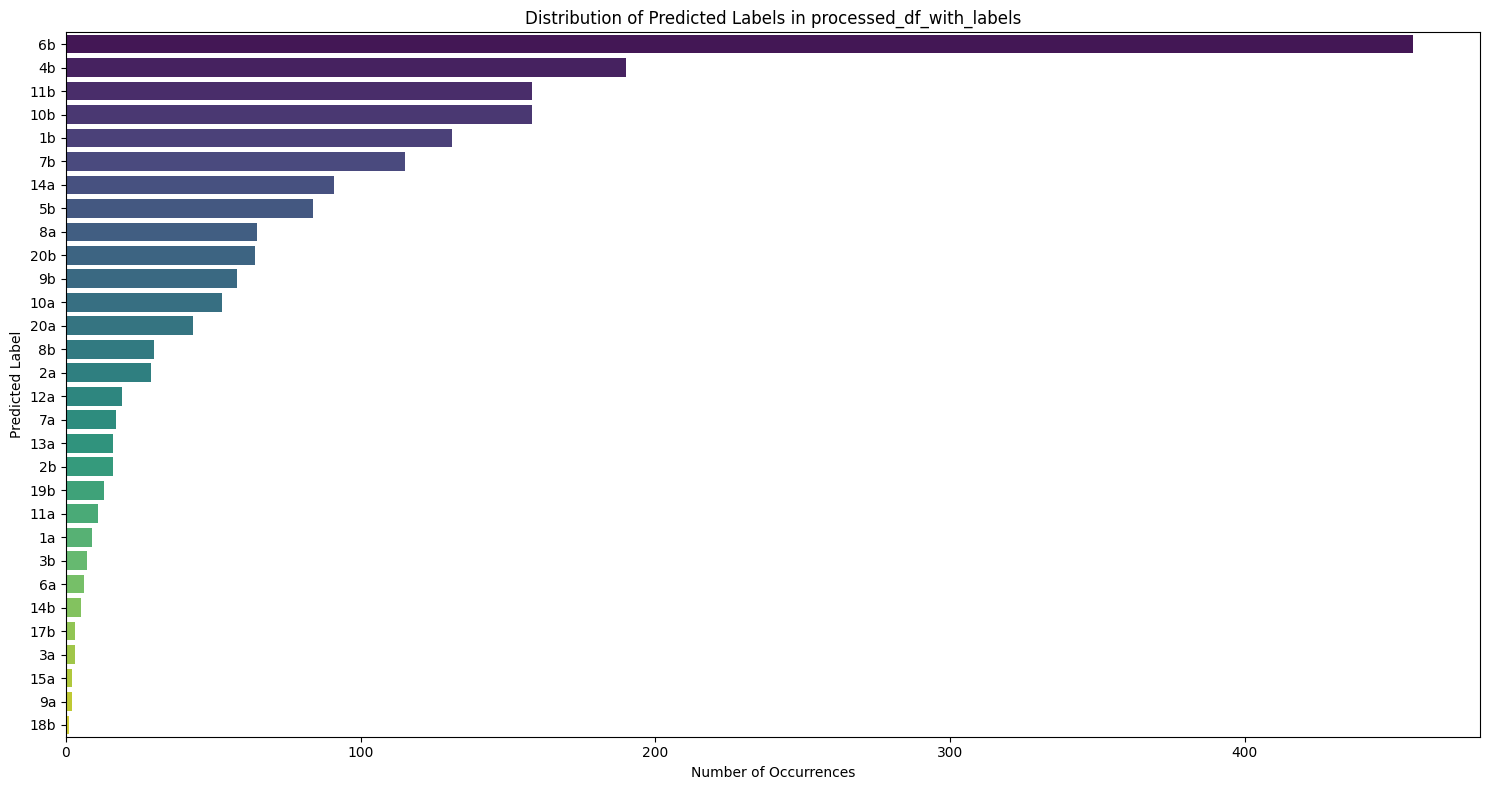

In [26]:
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# Function to safely parse the string representation of a list
def parse_labels_for_viz(labels_str):
    try:
        if isinstance(labels_str, str):
            # Replace single quotes with double quotes for valid JSON parsing if needed
            # or directly use ast.literal_eval
            return ast.literal_eval(labels_str)
        return []
    except (ValueError, SyntaxError):
        return []

# Apply the parsing function and explode the labels
processed_df_with_labels['predicted_labels_list'] = processed_df_with_labels['predicted_labels'].apply(parse_labels_for_viz)
processed_exploded_labels = processed_df_with_labels.explode('predicted_labels_list')

# Filter out any None or empty string labels that might result from parsing errors or missing labels
processed_exploded_labels = processed_exploded_labels[processed_exploded_labels['predicted_labels_list'].notna()]
processed_exploded_labels = processed_exploded_labels[processed_exploded_labels['predicted_labels_list'] != '']

# Count the occurrences of each unique label
label_counts = processed_exploded_labels['predicted_labels_list'].value_counts().reset_index()
label_counts.columns = ['label', 'count']

# Sort by count for better visualization
label_counts = label_counts.sort_values(by='count', ascending=False)

# Create the bar plot
plt.figure(figsize=(15, 8))
sns.barplot(x='count', y='label', data=label_counts, palette='viridis')
plt.title('Distribution of Predicted Labels in processed_df_with_labels')
plt.xlabel('Number of Occurrences')
plt.ylabel('Predicted Label')
plt.tight_layout()
plt.show()

The visualization above displays the frequency of each `predicted_label` within the `processed_df_with_labels` DataFrame. This bar chart helps us identify the most common themes or categories present in the processed data.

Key observations:
*   **Dominant Labels:** The labels with the longest bars are the most frequently assigned to the data points in `processed_df_with_labels`.
*   **Label Diversity:** The number of unique bars indicates the diversity of predicted labels.
*   **Relative Frequency:** The length of each bar shows the relative occurrence of each label compared to others.

/tmp/ipykernel_6429/2516021570.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='predicted_labels_list', data=crop_data, palette='viridis')


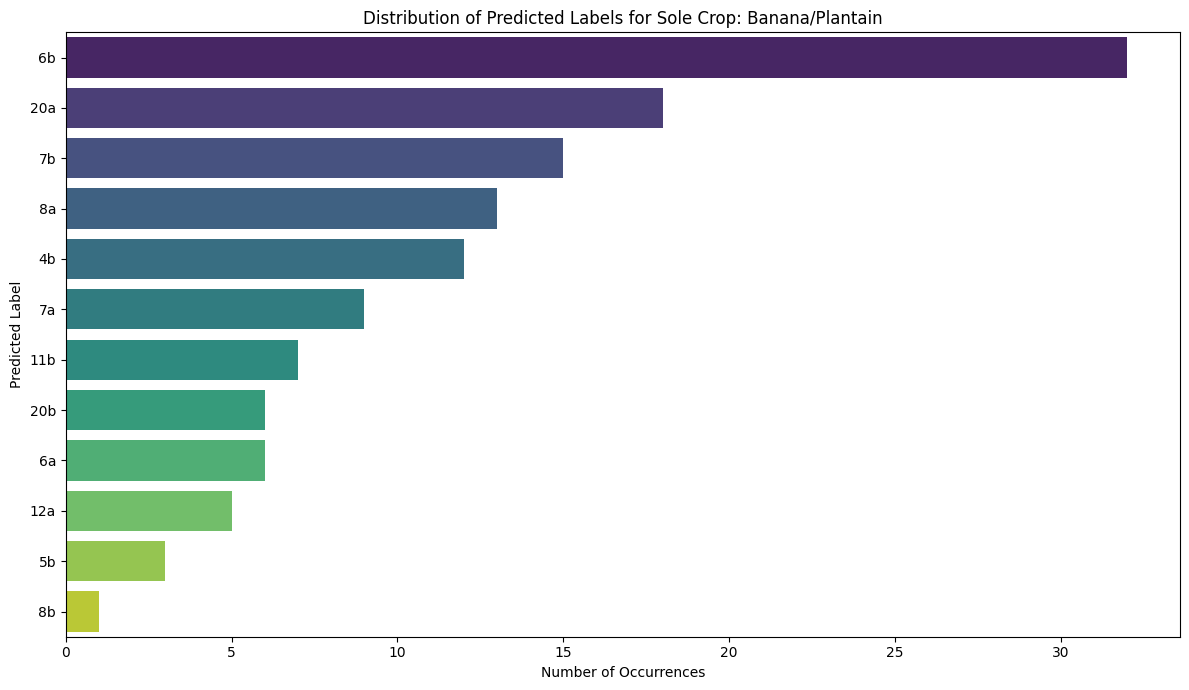

/tmp/ipykernel_6429/2516021570.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='predicted_labels_list', data=crop_data, palette='viridis')


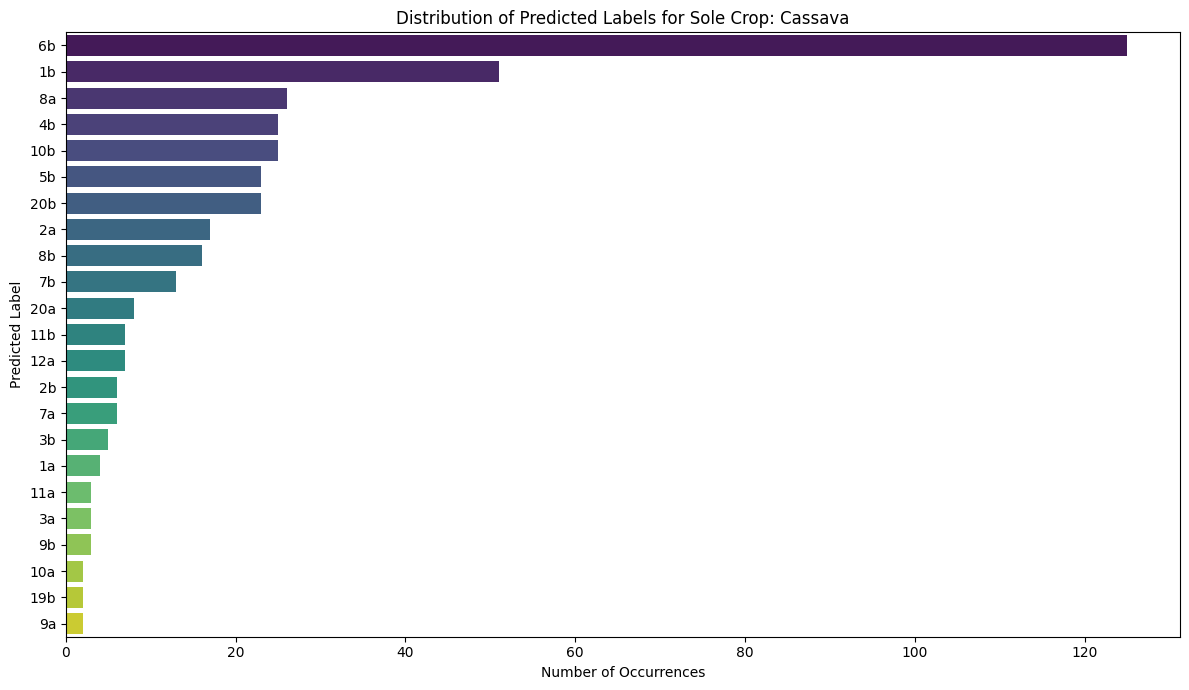

/tmp/ipykernel_6429/2516021570.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='predicted_labels_list', data=crop_data, palette='viridis')


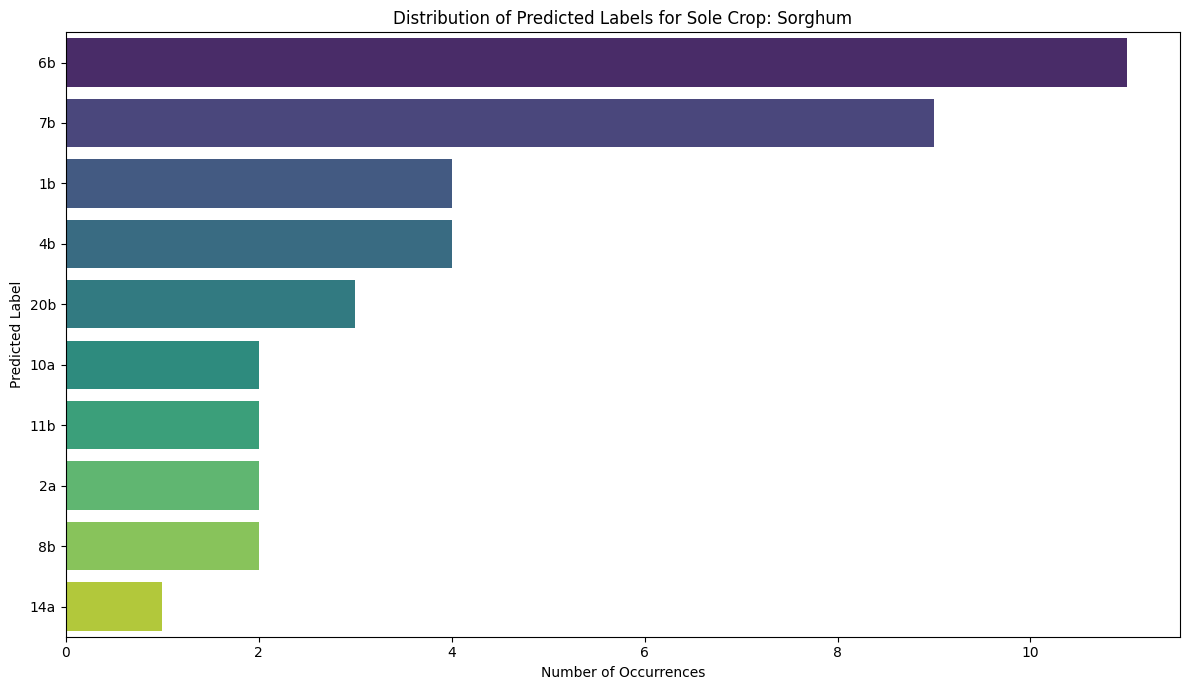

/tmp/ipykernel_6429/2516021570.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='predicted_labels_list', data=crop_data, palette='viridis')


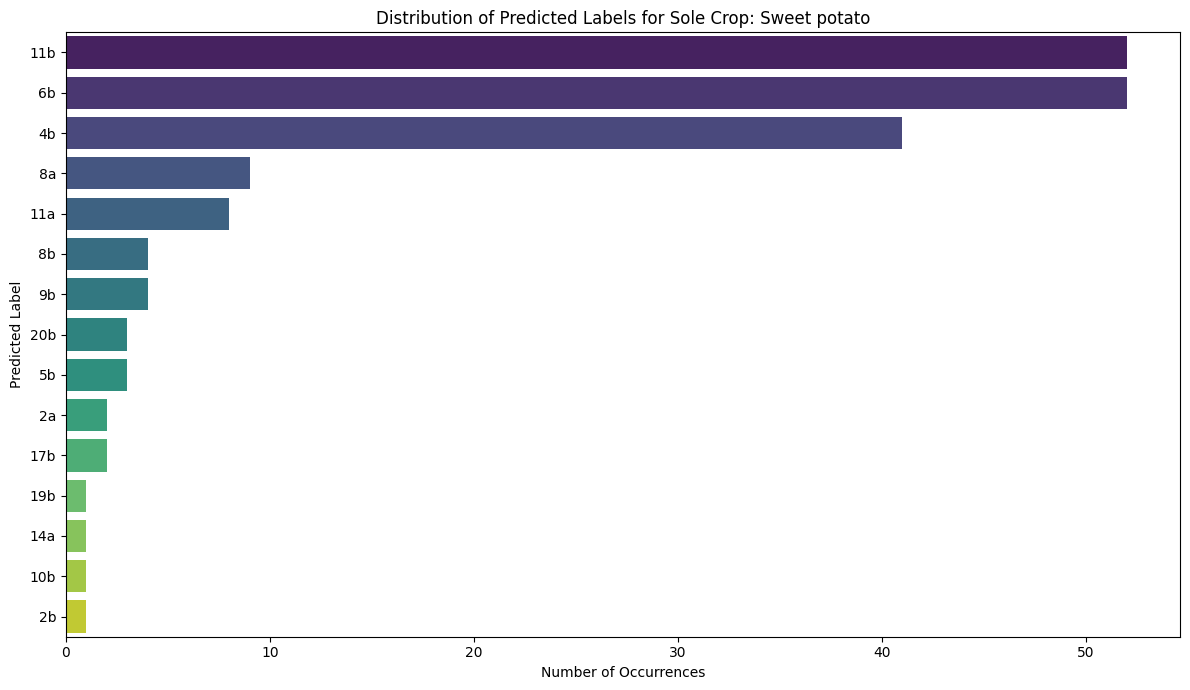

/tmp/ipykernel_6429/2516021570.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='predicted_labels_list', data=crop_data, palette='viridis')


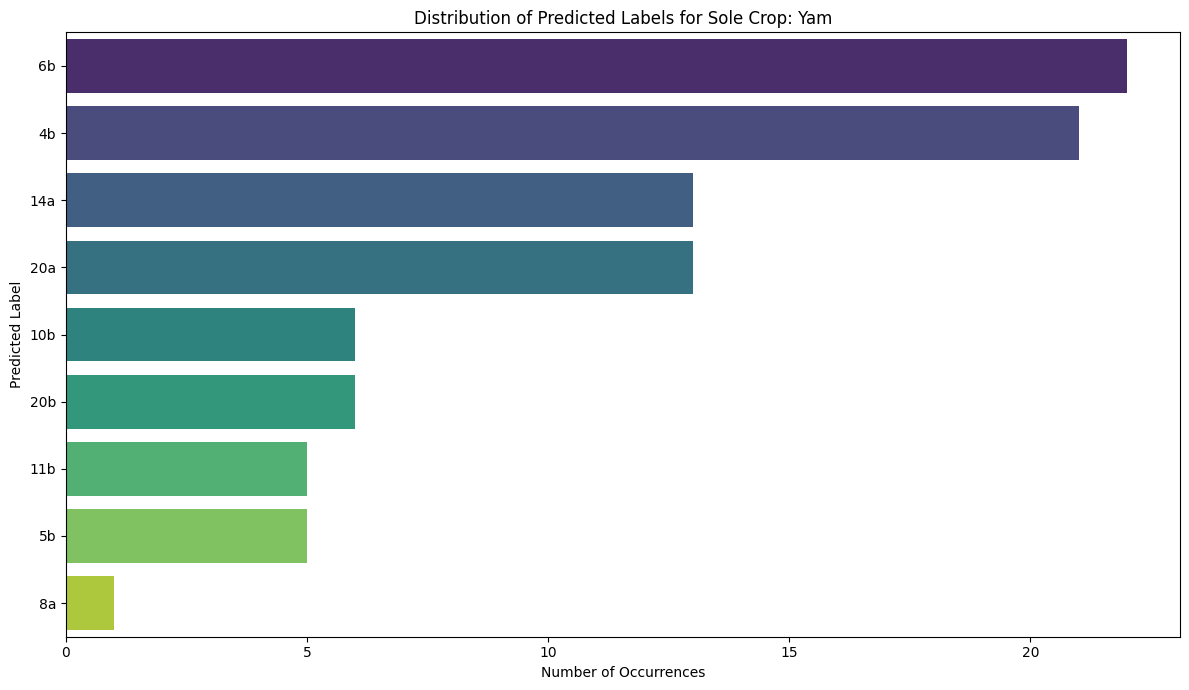

In [27]:
# Ensure 'sole_crop' is available in processed_exploded_labels
# If it's not directly present, we need to merge it from processed_df_with_labels
if 'sole_crop' not in processed_exploded_labels.columns:
    processed_exploded_labels = processed_exploded_labels.merge(
        processed_df_with_labels[['long_description', 'sole_crop']],
        on='long_description', # Assuming long_description is the common identifier
        how='left'
    )

# Count the occurrences of each label for each sole_crop
label_counts_by_crop = processed_exploded_labels.groupby(['sole_crop', 'predicted_labels_list']).size().reset_index(name='count')

# Filter out 'sole_crop' entries that might be None or empty if they exist after merge issues
label_counts_by_crop = label_counts_by_crop[label_counts_by_crop['sole_crop'].notna()]
label_counts_by_crop = label_counts_by_crop[label_counts_by_crop['sole_crop'] != '']

# Get unique sole crops for iteration
unique_sole_crops = label_counts_by_crop['sole_crop'].unique()

# Create a plot for each sole_crop
for crop in unique_sole_crops:
    fig = plt.figure(figsize=(12, 7)) # Adjust figure size for better readability
    crop_data = label_counts_by_crop[label_counts_by_crop['sole_crop'] == crop].sort_values(by='count', ascending=False)

    if not crop_data.empty:
        sns.barplot(x='count', y='predicted_labels_list', data=crop_data, palette='viridis')
        plt.title(f'Distribution of Predicted Labels for Sole Crop: {crop}')
        plt.xlabel('Number of Occurrences')
        plt.ylabel('Predicted Label')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No predicted labels found for sole crop: {crop}")